# PRAKTIKUM: Face Detection dan Klasifikasi Wajah

**Tugas:**
- A. Mengakses dataset Face Detection
- B. Preprocessing dataset
- C. Diagram alur proses (Mermaid)
- D. Implementasi model klasifikasi wajah + Testing

## A. Mengakses Dataset Face Detection

**Isi:**
- Dataset sudah di-crop (hanya wajah) dan di-resize
- Lokasi: `/content/drive/MyDrive/Dataset_Face_Only`
- Struktur: subfolder per kelas wajah (senang, sedih, marah, netral, dsb)

In [1]:
# Install dependencies jika diperlukan
!pip install tensorflow opencv-python matplotlib scikit-learn

In [2]:
from google.colab import drive
drive.mount('/content/drive')

dataset_path = '/content/drive/MyDrive/Dataset_Face_Only'
print(f"✅ Dataset diakses: {dataset_path}")

# Cek isi folder
import os
classes = os.listdir(dataset_path)
print(f"Kelas ditemukan: {classes}")
print(f"Jumlah kelas: {len(classes)}")

Mounted at /content/drive
✅ Dataset diakses: /content/drive/MyDrive/Dataset_Face_Only
Kelas ditemukan: ['Brad Pitt', 'Elizabeth Olsen', 'Hugh Jackman', 'Henry Cavill', 'Dwayne Johnson', 'Robert Downey Jr', 'Tom Cruise']
Jumlah kelas: 7


## B. Preprocessing Dataset

**Langkah Preprocessing:**
1. **Split data**: 80% training, 20% validation
2. **Data Augmentation**: rotasi, shift, flip untuk robustness
3. **Normalisasi**: pixel / 255 → [0,1]
4. **Resize**: 224x224 untuk input CNN

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data generator dengan augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

# Training generator
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation generator
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
val_generator = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print("✅ Preprocessing selesai!")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Jumlah kelas: {train_generator.num_classes}")

Found 416 images belonging to 7 classes.
Found 99 images belonging to 7 classes.
✅ Preprocessing selesai!
Training samples: 416
Validation samples: 99
Jumlah kelas: 7


## C. Diagram Alur Proses (Mermaid)

```mermaid
graph TB
    A([Dataset Face<br/>Google Drive]) --> B[Mount Drive]
    B --> C[Preprocessing:<br/>• Split 80/20<br/>• Augmentation<br/>• Resize 224x224<br/>• Normalisasi]
    C --> D[CNN Model:<br/>Conv2D + MaxPool<br/>Dense + Softmax]
    D --> E[Training 20 epochs<br/>Adam Optimizer]
    E --> F[Evaluation:<br/>Accuracy Plot]
    F --> G[Testing:<br/>Upload gambar baru<br/>Prediksi real-time]
    G --> H([Output:<br/>Kelas + Confidence])
    
    style A fill:#e1f5fe
    style H fill:#c8e6c9
```

## D. Implementasi Model Klasifikasi Wajah

**Tahap 1:** Arsitektur CNN
- 3 layer Conv2D (32,64,128 filter)
- MaxPooling2D setelah setiap Conv
- Dense 512 + Dropout 0.5
- Output softmax sesuai jumlah kelas

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Bangun model CNN
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model berhasil dibuat!")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Model berhasil dibuat!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,399,687 (169.37 MB)

 Trainable params: 44,399,687 (169.37 MB)

 Non-trainable params: 0 (0.00 B)

**Tahap 2:** Training Model (20 epochs)

In [5]:
# Training
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    verbose=1
)

# Simpan model
model.save('/content/drive/MyDrive/face_classification_model.h5')
print("✅ Model berhasil disimpan!")

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 134s 10s/step - accuracy: 0.2115 - loss: 2.7406 - val_accuracy: 0.1919 - val_loss: 1.9519
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 65s 5s/step - accuracy: 0.1635 - loss: 1.9293 - val_accuracy: 0.2020 - val_loss: 1.8962
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 64s 5s/step - accuracy: 0.2139 - loss: 1.8977 - val_accuracy: 0.2323 - val_loss: 1.8537
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 64s 5s/step - accuracy: 0.2524 - loss: 1.8768 - val_accuracy: 0.2020 - val_loss: 1.8584
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 65s 5s/step - accuracy: 0.2356 - loss: 1.8338 - val_accuracy: 0.3030 - val_loss: 1.8018
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 64s 5s/step - accuracy: 0.3486 - loss: 1.7500 - val_accuracy: 0.3333 - val_loss: 1.7566
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 65s 5s/step - accuracy: 0.3341 - loss: 1.6754 - val_accuracy: 0.3333 - val_loss: 1.7479
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 64s 5s/step - accuracy: 0.3438 - loss: 1.6604 - val_accuracy: 0.3838 - val_los

✅ Model berhasil disimpan!


**Tahap 3:** Visualisasi Hasil Training

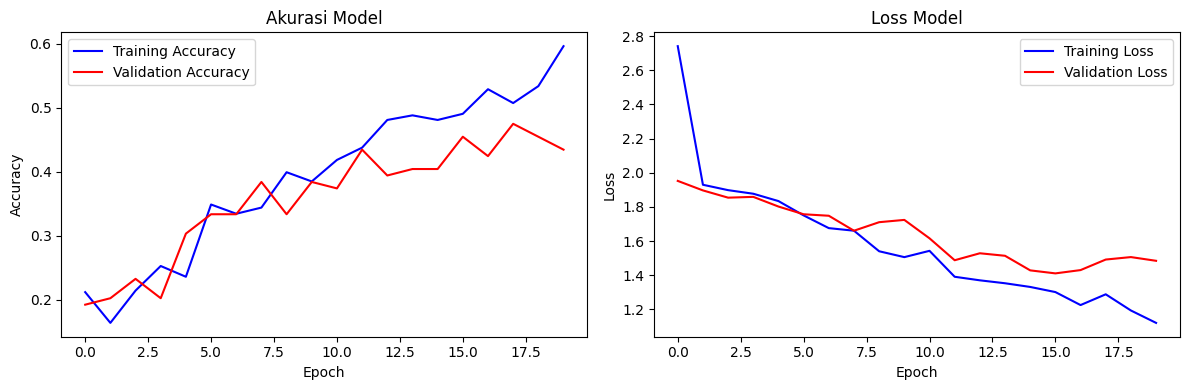

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], 'b-', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], 'r-', label='Validation Accuracy')
plt.title('Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], 'b-', label='Training Loss')
plt.plot(history.history['val_loss'], 'r-', label='Validation Loss')
plt.title('Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

**Tahap 4: TESTING / DEMO**

**Cara Testing:**
1. Klik tombol "Choose Files" di bawah
2. Upload foto wajah baru (.jpg/.png)
3. Model akan prediksi kelas & confidence secara otomatis

Kelas yang bisa dideteksi: ['Brad Pitt', 'Dwayne Johnson', 'Elizabeth Olsen', 'Henry Cavill', 'Hugh Jackman', 'Robert Downey Jr', 'Tom Cruise']

📁 UPLOAD GAMBAR WAJAH UNTUK TESTING:


Saving Robert Downey Jr_6.jpg to Robert Downey Jr_6.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step

📸 Gambar: Robert Downey Jr_6.jpg
🎯 Kelas Terprediksi: Robert Downey Jr
💯 Confidence: 79.2%


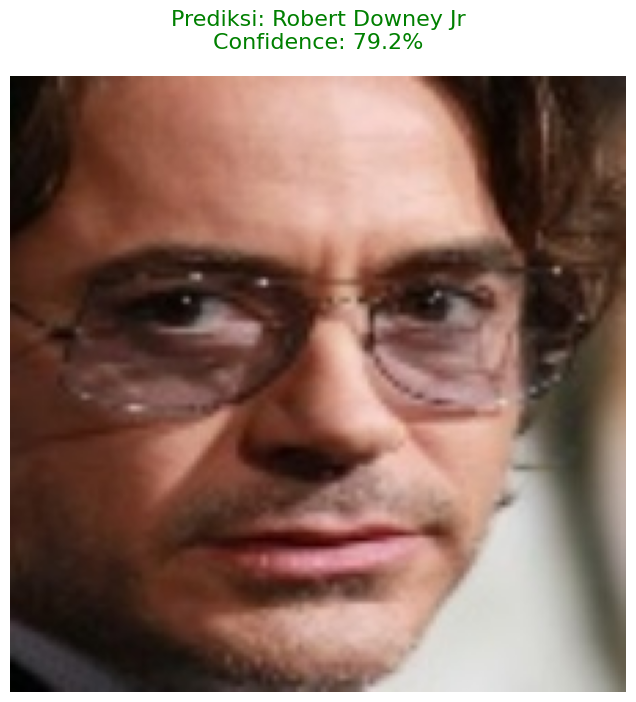

In [7]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load model terlatih
model_loaded = tf.keras.models.load_model('/content/drive/MyDrive/face_classification_model.h5')

class_names = list(train_generator.class_indices.keys())
print("Kelas yang bisa dideteksi:", class_names)

print("\n📁 UPLOAD GAMBAR WAJAH UNTUK TESTING:")
uploaded = files.upload()

for filename in uploaded.keys():
    # Preprocess
    img = image.load_img(filename, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediksi
    predictions = model_loaded.predict(img_array)
    predicted_class = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class] * 100

    predicted_label = class_names[predicted_class]

    print("\n" + "="*50)
    print(f"📸 Gambar: {filename}")
    print(f"🎯 Kelas Terprediksi: {predicted_label}")
    print(f"💯 Confidence: {confidence:.1f}%")
    print("="*50)

    # Visualisasi
    plt.figure(figsize=(10, 8))
    plt.imshow(img_array[0])
    plt.title(f'Prediksi: {predicted_label}\nConfidence: {confidence:.1f}%',
              fontsize=16, color='green', pad=20)
    plt.axis('off')
    plt.show()

Kelas yang bisa dideteksi: ['Brad Pitt', 'Dwayne Johnson', 'Elizabeth Olsen', 'Henry Cavill', 'Hugh Jackman', 'Robert Downey Jr', 'Tom Cruise']

📁 UPLOAD GAMBAR WAJAH UNTUK TESTING:


Saving Dwayne Johnson_4.jpg to Dwayne Johnson_4.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step

📸 Gambar: Dwayne Johnson_4.jpg
🎯 Kelas Terprediksi: Dwayne Johnson
💯 Confidence: 97.0%


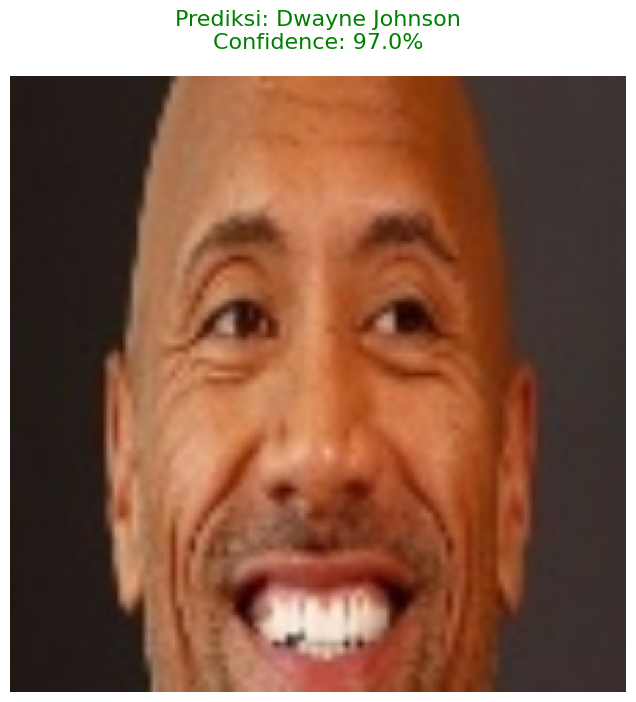

In [8]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load model terlatih
model_loaded = tf.keras.models.load_model('/content/drive/MyDrive/face_classification_model.h5')

class_names = list(train_generator.class_indices.keys())
print("Kelas yang bisa dideteksi:", class_names)

print("\n📁 UPLOAD GAMBAR WAJAH UNTUK TESTING:")
uploaded = files.upload()

for filename in uploaded.keys():
    # Preprocess
    img = image.load_img(filename, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediksi
    predictions = model_loaded.predict(img_array)
    predicted_class = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class] * 100

    predicted_label = class_names[predicted_class]

    print("\n" + "="*50)
    print(f"📸 Gambar: {filename}")
    print(f"🎯 Kelas Terprediksi: {predicted_label}")
    print(f"💯 Confidence: {confidence:.1f}%")
    print("="*50)

    # Visualisasi
    plt.figure(figsize=(10, 8))
    plt.imshow(img_array[0])
    plt.title(f'Prediksi: {predicted_label}\nConfidence: {confidence:.1f}%',
              fontsize=16, color='green', pad=20)
    plt.axis('off')
    plt.show()

Kelas yang bisa dideteksi: ['Brad Pitt', 'Dwayne Johnson', 'Elizabeth Olsen', 'Henry Cavill', 'Hugh Jackman', 'Robert Downey Jr', 'Tom Cruise']

📁 UPLOAD GAMBAR WAJAH UNTUK TESTING:


Saving Tom Cruise_3.jpg to Tom Cruise_3.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step

📸 Gambar: Tom Cruise_3.jpg
🎯 Kelas Terprediksi: Tom Cruise
💯 Confidence: 53.8%


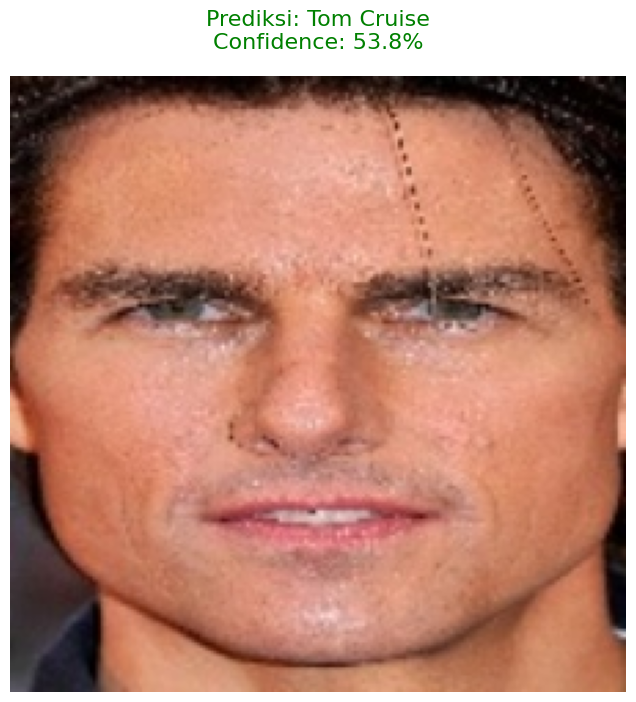

In [9]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load model terlatih
model_loaded = tf.keras.models.load_model('/content/drive/MyDrive/face_classification_model.h5')

class_names = list(train_generator.class_indices.keys())
print("Kelas yang bisa dideteksi:", class_names)

print("\n📁 UPLOAD GAMBAR WAJAH UNTUK TESTING:")
uploaded = files.upload()

for filename in uploaded.keys():
    # Preprocess
    img = image.load_img(filename, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediksi
    predictions = model_loaded.predict(img_array)
    predicted_class = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class] * 100

    predicted_label = class_names[predicted_class]

    print("\n" + "="*50)
    print(f"📸 Gambar: {filename}")
    print(f"🎯 Kelas Terprediksi: {predicted_label}")
    print(f"💯 Confidence: {confidence:.1f}%")
    print("="*50)

    # Visualisasi
    plt.figure(figsize=(10, 8))
    plt.imshow(img_array[0])
    plt.title(f'Prediksi: {predicted_label}\nConfidence: {confidence:.1f}%',
              fontsize=16, color='green', pad=20)
    plt.axis('off')
    plt.show()

Kelas yang bisa dideteksi: ['Brad Pitt', 'Dwayne Johnson', 'Elizabeth Olsen', 'Henry Cavill', 'Hugh Jackman', 'Robert Downey Jr', 'Tom Cruise']

📁 UPLOAD GAMBAR WAJAH UNTUK TESTING:


Saving Dwayne Johnson_0.jpg to Dwayne Johnson_0.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step

📸 Gambar: Dwayne Johnson_0.jpg
🎯 Kelas Terprediksi: Hugh Jackman
💯 Confidence: 25.5%


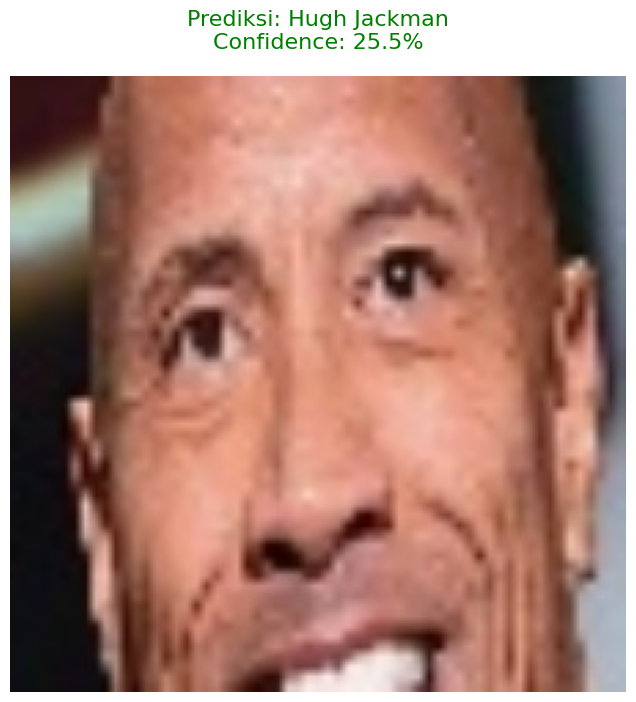

In [10]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load model terlatih
model_loaded = tf.keras.models.load_model('/content/drive/MyDrive/face_classification_model.h5')

class_names = list(train_generator.class_indices.keys())
print("Kelas yang bisa dideteksi:", class_names)

print("\n📁 UPLOAD GAMBAR WAJAH UNTUK TESTING:")
uploaded = files.upload()

for filename in uploaded.keys():
    # Preprocess
    img = image.load_img(filename, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediksi
    predictions = model_loaded.predict(img_array)
    predicted_class = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class] * 100

    predicted_label = class_names[predicted_class]

    print("\n" + "="*50)
    print(f"📸 Gambar: {filename}")
    print(f"🎯 Kelas Terprediksi: {predicted_label}")
    print(f"💯 Confidence: {confidence:.1f}%")
    print("="*50)

    # Visualisasi
    plt.figure(figsize=(10, 8))
    plt.imshow(img_array[0])
    plt.title(f'Prediksi: {predicted_label}\nConfidence: {confidence:.1f}%',
              fontsize=16, color='green', pad=20)
    plt.axis('off')
    plt.show()